In [2]:
# Import python libraries
#import json
import os
import pathlib
from glob import glob

import earthpy.api.appeears as eaapp
import earthpy
import geopandas as gpd
import hvplot.pandas
import hvplot.xarray
import pandas as pd
import rioxarray as rxr
import xarray as xr
import holoviews as hv
import matplotlib.pyplot as plt
import osmnx as osm

# Look at San Carlos Apache Reservation

In [2]:
# Search OSM for San Carlos Apache using geocode_to_gdf
osm_way_id = 9436141

# Retrieve polygon boundary
scat_boundary = osm.geocode_to_gdf(
    "R9436141",
    by_osmid=True
)

scat_boundary

,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"MULTIPOLYGON (((-110.75277 33.17056, -110.7506...",-110.752774,32.875137,-109.495406,33.817328,333989162,relation,9436141,33.335742,-110.109503,boundary,aboriginal_lands,25,0.066677,aboriginal_lands,San Carlos Apache Indian Reservation,"San Carlos Apache Indian Reservation, Arizona,..."


<Axes: >

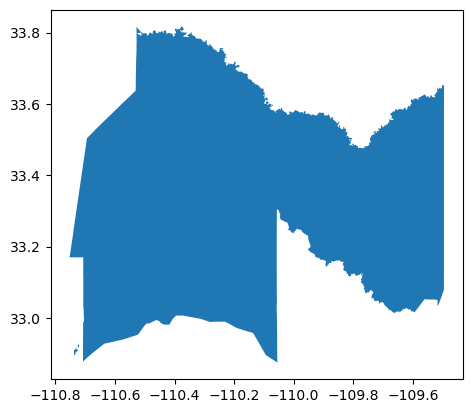

In [3]:
scat_boundary.plot()

In [1]:
# Create a project for file management
project = earthpy.Project(
    "San Carlos Vegetation",
    dirname="scat-vegetation"
)

NameError: name 'earthpy' is not defined

In [6]:
# Initialize AppeearsDownloader for MODIS NDVI data
ndvi_downloader = eaapp.AppeearsDownloader(
    download_key='scat',
    project=project,
    product='MOD13Q1.061',
    layer='_250m_16_days_NDVI',
    start_date="06-01",
    end_date="09-01",
    recurring=True,
    year_range=[2015, 2025],
    polygon=scat_boundary
)

In [7]:
# Download the prepared download -- this can take some time!
ndvi_downloader.download_files(cache=False)

No stored credentials found for urs.earthdata.nasa.gov. Please log in.


/opt/conda/lib/python3.11/site-packages/earthpy/api/auth.py:192: UserWarning: Setting credentials not supported for 'netrc' backend.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/earthpy/api/auth.py:196: UserWarning: Failed to store credentials with 'keyring': No recommended backend was available. Install a recommended 3rd party backend package; or, install the keyrings.alt package if you want to use the non-recommended backends. See https://pypi.org/project/keyring for details.
  warnings.warn(


Credentials stored using 'env' backend.


KeyboardInterrupt: 

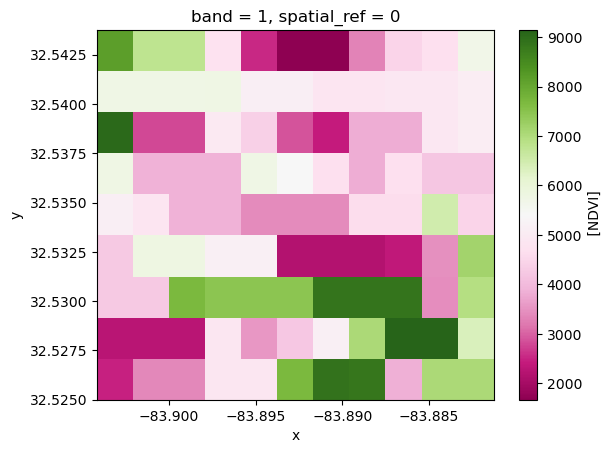

In [8]:
# Open the GeoTIFF
tif_path = "/workspaces/data/scat-vegetation/scat/MOD13Q1.061_2015137_to_2025244/MOD13Q1.061__250m_16_days_NDVI_doy2015145000000_aid0001.tif"

raster = rxr.open_rasterio(tif_path)

# Plot
raster.plot(cmap="PiYG")

plt.show()